<a href="https://colab.research.google.com/github/NishantKhupase/ML_Task/blob/main/Session_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving car_price_prediction_.csv to car_price_prediction_.csv


In [4]:
filepath = '/content/car_price_prediction_.csv'
df = pd.read_csv(filepath)
df.head(10)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
5,6,Audi,2019,2.4,Diesel,Automatic,246553,Like New,88969.76,Q7
6,7,Audi,2020,4.0,Electric,Automatic,135486,Used,63498.75,Q5
7,8,Tesla,2017,5.3,Hybrid,Automatic,83030,New,17381.19,Model Y
8,9,Honda,2023,5.7,Electric,Manual,120360,Like New,15905.62,Civic
9,10,Ford,2010,1.5,Electric,Automatic,135009,Like New,9560.22,Explorer


In [21]:
print("Missing Values: ",df.isnull().sum())
print("\nPercentage of missing values: ",(df.isnull().sum()/len(df)*100))
print("\nDuplicate row: ",df.duplicated().sum())
print("\nFinal Datset Shape: ",df.shape)

Missing Values:  Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

Percentage of missing values:  Car ID          0.0
Brand           0.0
Year            0.0
Engine Size     0.0
Fuel Type       0.0
Transmission    0.0
Mileage         0.0
Condition       0.0
Price           0.0
Model           0.0
dtype: float64

Duplicate row:  0

Final Datset Shape:  (2500, 10)


In [63]:
print("statistical summary:\n",df.describe())
print("\nFor Targated Variable:")
print("MIN: ",df["Price"].min())
print("MAX: ",df["Price"].max())
print("MEAN: ",df["Price"].mean())
print("MEDIAN: ",df["Price"].median())

statistical summary:
            Car ID       Year  Engine Size        Mileage         Price
count  2500.00000  2500.0000  2500.000000    2500.000000   2500.000000
mean   1250.50000  2011.6268     3.465240  149749.844800  52638.022532
std     721.83216     6.9917     1.432053   87919.952034  27295.833455
min       1.00000  2000.0000     1.000000      15.000000   5011.270000
25%     625.75000  2005.0000     2.200000   71831.500000  28908.485000
50%    1250.50000  2012.0000     3.400000  149085.000000  53485.240000
75%    1875.25000  2018.0000     4.700000  225990.500000  75838.532500
max    2500.00000  2023.0000     6.000000  299967.000000  99982.590000

For Targated Variable:
MIN:  5011.27
MAX:  99982.59
MEAN:  52638.022532
MEDIAN:  53485.240000000005


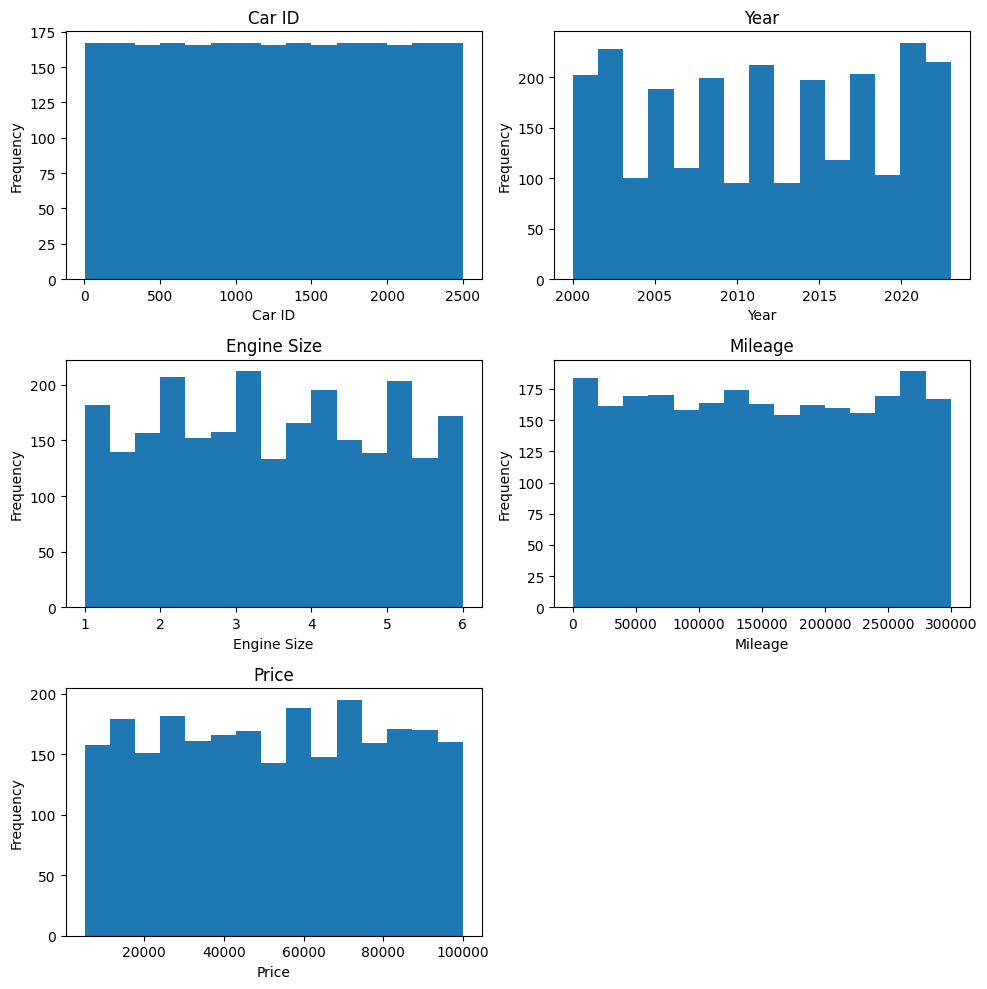

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns


columns = ["Car ID", "Year", "Engine Size", "Mileage", "Price"]

plt.figure(figsize=(10,10))

for i, col in enumerate(columns, 1):
    plt.subplot(3, 2, i)
    plt.hist(df[col], bins=15)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')


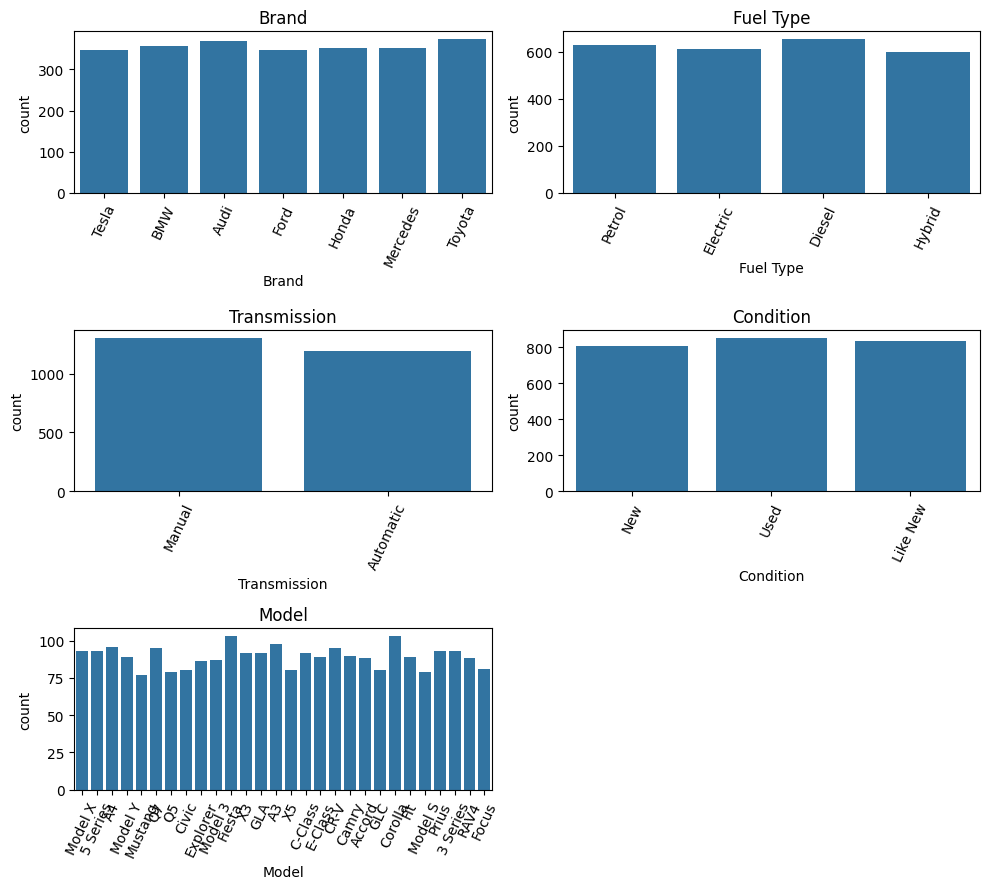

In [67]:
cat_cols = df.select_dtypes(include=["object"]).columns

print(cat_cols)

plt.figure(figsize=(10,9))

for i,col in enumerate(cat_cols,1):
  plt.subplot(3,2,i)
  sns.countplot(data=df,x=col)
  plt.title(col)
  plt.xticks(rotation=65)

plt.tight_layout()
plt.show()

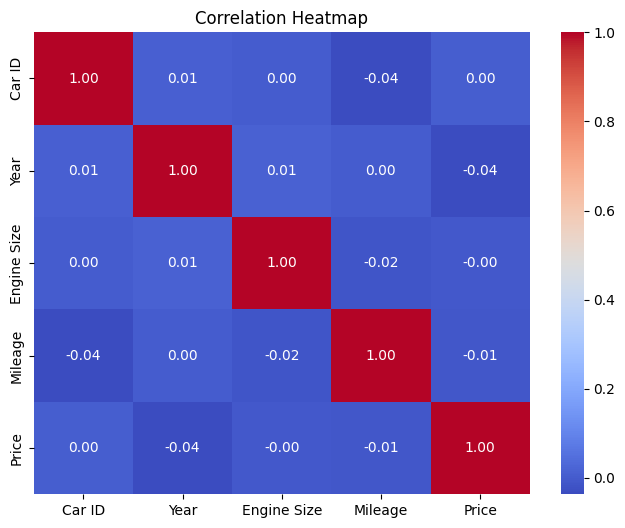

In [58]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=["number"])

# Calculate correlation matrix
correlation = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [59]:
  # Independent Features (X)
  X = df.drop("Price", axis=1)

  # Dependent Feature (y)
  y = df["Price"]

  print("Independent Features (X):")
  print(X.columns)

  print("\nDependent Feature (y):")
  print(y.name)

Independent Features (X):
Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Model'],
      dtype='object')

Dependent Feature (y):
Price


In [68]:
# Find categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Display categorical column names
print("Categorical Columns:")
print(cat_cols)

# Show first 5 rows before encoding
print("\nBefore Encoding:")
print(df[["Brand", "Fuel Type"]].head())

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, dtype=int)

# Show first 5 rows after encoding
print("\nAfter Encoding (Brand):")
print(df_encoded.filter(like="Brand").head())

print("\nAfter Encoding (Fuel Type):")
print(df_encoded.filter(like="Fuel Type").head())

# Display first 5 rows of encoded dataset
print("\nEncoded Dataset:")
print(df_encoded.head())

Categorical Columns:
Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')

Before Encoding:
   Brand Fuel Type
0  Tesla    Petrol
1    BMW  Electric
2   Audi  Electric
3  Tesla    Diesel
4   Ford    Diesel

After Encoding (Brand):
   Brand_Audi  Brand_BMW  Brand_Ford  Brand_Honda  Brand_Mercedes  \
0           0          0           0            0               0   
1           0          1           0            0               0   
2           1          0           0            0               0   
3           0          0           0            0               0   
4           0          0           1            0               0   

   Brand_Tesla  Brand_Toyota  
0            1             0  
1            0             0  
2            0             0  
3            1             0  
4            0             0  

After Encoding (Fuel Type):
   Fuel Type_Diesel  Fuel Type_Electric  Fuel Type_Hybrid  Fuel Type_Petrol
0                 0             

In [61]:
from sklearn.preprocessing import StandardScaler

# Independent Features (Remove target variable)
X = df_encoded.drop("Price", axis=1)

# Dependent Feature
y = df_encoded["Price"]

# Create StandardScaler object
scaler = StandardScaler()

# Apply Standard Scaling
X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print(X_scaled.head())

     Car ID      Year  Engine Size   Mileage  Brand_Audi  Brand_BMW  \
0 -1.731358  0.625610    -0.813848 -0.397234   -0.415461  -0.408820   
1 -1.729972  0.911720     0.652872 -0.074626   -0.415461   2.446066   
2 -1.728587  0.196444     0.722716  0.362347    2.406965  -0.408820   
3 -1.727201 -0.089667     0.443340 -0.922249   -0.415461  -0.408820   
4 -1.725816 -0.375778    -0.604316  0.833415   -0.415461  -0.408820   

   Brand_Ford  Brand_Honda  Brand_Mercedes  Brand_Tesla  ...  Model_Model S  \
0   -0.401460    -0.404813       -0.405482     2.486746  ...      -0.180641   
1   -0.401460    -0.404813       -0.405482    -0.402132  ...      -0.180641   
2   -0.401460    -0.404813       -0.405482    -0.402132  ...      -0.180641   
3   -0.401460    -0.404813       -0.405482     2.486746  ...      -0.180641   
4    2.490906    -0.404813       -0.405482    -0.402132  ...      -0.180641   

   Model_Model X  Model_Model Y  Model_Mustang  Model_Prius  Model_Q5  \
0       5.087408      -0.